In [ ]:
# @title
from IPython.display import HTML, display

cover_html = """
<div style="
    background-color: white;
    color: #222;
    padding: 40px 40px 30px 40px;
    border-radius: 15px;
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 4px 20px rgba(0,0,0,0.1);
    margin: 20px 0;
    text-align: center;
    position: relative;
">

    <!-- Top Banner Image -->
    <img src="https://www.redage.org/sites/default/files/img-logo-institucion/logo-itesm.png"
         style="width: 100%; max-width: 800px; border-radius: 12px; margin-bottom: 30px; box-shadow: 0 2px 10px rgba(0,0,0,0.1);"
         alt="Banner">

    <!-- Title -->
    <h1 style="font-size: 2.5em; margin-bottom: 10px; color: #111;">Red Neuronal Pokèmon</h1>

    <img src="https://i.pinimg.com/originals/5c/32/67/5c32670ac7a737973c25d203c74c3911.gif"
     style="width: 100%; max-width: 450px; border-radius: 12px; margin-bottom: 30px; box-shadow: 0 2px 10px rgba(0,0,0,0.1);"
     alt="Banner">


    <!-- Subject -->
    <p style="font-size: 1.2em; margin: 10px 0; color: #333;">
        <b>Diseño de Redes Neuronales e Inteligencia Artificial (Gpo 202)</b>
    </p>

    <!-- Horizontal line -->
    <hr style="width: 50%; margin: 30px auto; border: 1px solid #ccc;">

        <!-- Team Members -->
    <div style="font-size: 1.1em; line-height: 1.6; color: #444;">
    <strong>Prof. Andrea Torres Calderón</strong><br><br>
        <strong>Team Members:</strong><br>
        • Arantza Ramírez Ortiz - - - A01800288<br>

        • Diego Alejandro Parra Ruíz - - - A0180102<br>
    </div>

    <!-- Date -->
    <p style="margin-top: 25px; font-size: 1em; color: #555;">
        <strong>Fecha:</strong> 28 de Noviembre del 2025
    </p>

</div>
"""

display(HTML(cover_html))


# 1. Selección del Problema


# 2. Librerías e instalaciones

## 2.1 Instalaciones

In [ ]:
#Pip Installs
!pip install torchview
!pip install torchview graphviz
!apt-get install graphviz
!pip install tensorboard

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


## 2.2 Librerías

In [ ]:
#Librerías

import zipfile

from torchvision import datasets, transforms

import re

import os

from torch.utils.data import DataLoader, random_split, Dataset
import torch

import pandas as pd


from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np # Import numpy for explicit type conversion


import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from torchvision.utils import make_grid
import matplotlib.pyplot as plt

import torch.nn as nn
import torchvision.models as models
import numpy as np
import torch
from torchview import draw_graph

from torch.utils.tensorboard import SummaryWriter

from tqdm.auto import tqdm


# 3 Carga y Limpieza del Dataset

## 3.1 Carga de Imágenes y CSV

In [ ]:
# ZIP with Images Upload
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
# Zip Extraction
local_zip = 'archive (1).zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/data/images')
zip_ref.close()

In [ ]:
# CSV Upload
uploaded = files.upload()

Saving pokemon_data.csv to pokemon_data.csv


In [ ]:
# Base Imge Extraction
base_dataset = datasets.ImageFolder(
    root="/content/data/images",
    transform=None
)

In [ ]:
#Dataframization of CSV
df = pd.read_csv("pokemon_data.csv")
df.dtypes
df.head()
df.columns


Index(['Pokemon', 'Type', 'Species', 'Height', 'Weight', 'Abilities',
       'EV Yield', 'Catch Rate', 'Base Friendship', 'Base Exp', 'Growth Rate',
       'Egg Groups', 'Gender', 'Egg Cycles', 'HP Base', 'HP Min', 'HP Max',
       'Attack Base', 'Attack Min', 'Attack Max', 'Defense Base',
       'Defense Min', 'Defense Max', 'Special Attack Base',
       'Special Attack Min', 'Special Attack Max', 'Special Defense Base',
       'Special Defense Min', 'Special Defense Max', 'Speed Base', 'Speed Min',
       'Speed Max'],
      dtype='object')

## 3.2 Pokemon Name String Cleansing

In [ ]:
# Name and Type Cleansing

def clean_name(s):
    s = s.lower()
    s = re.sub(r'[^a-z0-9]', '', s)
    return s

def primary_type(s):
    return s.split(',')[0]


df["Pokemon"] = df["Pokemon"].apply(clean_name)

df["Mono Type"] = df["Type"].apply(primary_type)

display(df.head(30))


,Pokemon,Type,Species,Height,Weight,Abilities,EV Yield,Catch Rate,Base Friendship,Base Exp,...,Special Attack Base,Special Attack Min,Special Attack Max,Special Defense Base,Special Defense Min,Special Defense Max,Speed Base,Speed Min,Speed Max,Mono Type
0,abomasnow,"Grass, Ice",Frost Tree Pokémon,2.2 m (7′03″),135.5 kg (298.7 lbs),"1. Snow Warning, Soundproof (hidden ability)","1 Attack, 1 Sp. Atk","60 (7.8% with PokéBall, full HP)",50 (normal),173,...,92,170,311,85,157,295,60,112,240,Grass
1,megaabomasnow,"Grass, Ice",Frost Tree Pokémon,2.7 m (8′10″),185.0 kg (407.9 lbs),1. Snow Warning,"1 Attack, 1 Sp. Atk","60 (7.8% with PokéBall, full HP)",50 (normal),208,...,132,242,399,105,193,339,30,58,174,Grass
2,abra,Psychic,Psi Pokémon,0.9 m (2′11″),19.5 kg (43.0 lbs),"1. Synchronize, 2. Inner Focus, Magic Guard (h...",1 Sp. Atk,"200 (26.1% with PokéBall, full HP)",50 (normal),62,...,105,193,339,55,103,229,90,166,306,Psychic
3,absol,Dark,Disaster Pokémon,1.2 m (3′11″),47.0 kg (103.6 lbs),"1. Pressure, 2. Super Luck, Justified (hidden ...",2 Attack,"30 (3.9% with PokéBall, full HP)",35 (lower than normal),163,...,75,139,273,60,112,240,75,139,273,Dark
4,megaabsol,Dark,Disaster Pokémon,1.2 m (3′11″),49.0 kg (108.0 lbs),1. Magic Bounce,2 Attack,"30 (3.9% with PokéBall, full HP)",35 (lower than normal),198,...,115,211,361,60,112,240,115,211,361,Dark
5,accelgor,Bug,Shell Out Pokémon,0.8 m (2′07″),25.3 kg (55.8 lbs),"1. Hydration, 2. Sticky Hold, Unburden (hidden...",2 Speed,"75 (9.8% with PokéBall, full HP)",50 (normal),173,...,100,184,328,60,112,240,145,265,427,Bug
6,aegislashshieldforme,"Steel, Ghost",Royal Sword Pokémon,1.7 m (5′07″),53.0 kg (116.8 lbs),1. Stance Change,"2 Defense, 1 Sp. Def","45 (5.9% with PokéBall, full HP)",50 (normal),234,...,50,94,218,140,256,416,60,112,240,Steel
7,aegislashbladeforme,"Steel, Ghost",Royal Sword Pokémon,1.7 m (5′07″),53.0 kg (116.8 lbs),1. Stance Change,"2 Attack, 1 Sp. Atk","45 (5.9% with PokéBall, full HP)",50 (normal),234,...,140,256,416,50,94,218,60,112,240,Steel
8,aerodactyl,"Rock, Flying",Fossil Pokémon,1.8 m (5′11″),59.0 kg (130.1 lbs),"1. Rock Head, 2. Pressure, Unnerve (hidden abi...",2 Speed,"45 (5.9% with PokéBall, full HP)",50 (normal),180,...,60,112,240,75,139,273,130,238,394,Rock
9,megaaerodactyl,"Rock, Flying",Fossil Pokémon,2.1 m (6′11″),79.0 kg (174.2 lbs),1. Tough Claws,2 Speed,"45 (5.9% with PokéBall, full HP)",50 (normal),215,...,70,130,262,95,175,317,150,274,438,Rock


## 3.3 Name Extraction from Image Folder Path

In [ ]:
# ROOT/name/img Unification

image_paths = []

for root, dirs, files in os.walk("/content/data/images"):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp")):
            image_paths.append(os.path.join(root, f))

image_paths.sort()
image_paths[0]

'/content/data/images/images/Abomasnow/0.jpg'

In [ ]:
#Extract Pokemon name from Path

def extract_name_from_path(path):
    # folder name before the image file
    folder = os.path.basename(os.path.dirname(path))
    return clean_name(folder)

extract_name_from_path("/content/data/images/Delphox/p001.png")

'delphox'

## 3.4 Normalization of Stats

In [ ]:

stat_cols = ['HP Max','Attack Max','Defense Max','Special Attack Max','Special Defense Max','Speed Max']

# Compute per-stat mean & std across ALL Pokémon
stat_mean = df[stat_cols].mean()
stat_std = df[stat_cols].std()

print("MEAN:\n", stat_mean)
print("\nSTD:\n", stat_std)

MEAN:
 HP Max                 346.320165
Attack Max             286.658436
Defense Max            273.128395
Special Attack Max     269.203292
Special Defense Max    267.483951
Speed Max              262.236214
dtype: float64

STD:
 HP Max                 54.611949
Attack Max             70.480682
Defense Max            67.633071
Special Attack Max     72.081381
Special Defense Max    60.674744
Speed Max              66.380519
dtype: float64


In [ ]:
df_normalized = df.copy()
df_normalized[stat_cols] = (df[stat_cols] - stat_mean) / stat_std


In [ ]:
#Dictionary with Prediction Stats

stats_dict = {
    row['Pokemon']: ((row[stat_cols] - stat_mean) / stat_std).values
    for _, row in df.iterrows()
}

print(stats_dict["delphox"])



[0.1406255509070585 -0.3782374882739858 -0.09061240291820725
 1.245768411305846 0.9973845004572873 1.126291071764096]


In [ ]:
#Type Dictionary

types = sorted(df["Mono Type"].unique())
label_map = {t: i for i, t in enumerate(types)}

num_types = len(label_map)
print(label_map)
print(num_types)

{'Bug': 0, 'Dark': 1, 'Dragon': 2, 'Electric': 3, 'Fairy': 4, 'Fighting': 5, 'Fire': 6, 'Flying': 7, 'Ghost': 8, 'Grass': 9, 'Ground': 10, 'Ice': 11, 'Normal': 12, 'Poison': 13, 'Psychic': 14, 'Rock': 15, 'Steel': 16, 'Water': 17}
18


## 3.5 Name - Type - Stat Builder

In [ ]:
#Extraction of existing Pokemon in CSV - Image Folder

valid_stats_samples = []
mono_types = []


for img_path in image_paths:
    name = extract_name_from_path(img_path)
    if name in stats_dict:
        valid_stats_samples.append((img_path, stats_dict[name]))



for img_path in image_paths:
    name = extract_name_from_path(img_path)

    mono_row = df[df["Pokemon"] == name]

    if len(mono_row) == 0:
      continue

    mono_type = mono_row["Mono Type"].iloc[0]
    mono_types.append((img_path, mono_type))

print(mono_types[0][1])
print(mono_types[1000][0])



Grass
/content/data/images/images/Kadabra/2.jpg


## 3.5 Dataset Division

### 3.5.1 Data Split

In [ ]:
#Type Split
type_train_size = int(0.8 * len(mono_types))
type_val_size   = int(0.2 * len(mono_types))
type_test_size  = len(mono_types) - type_train_size - type_val_size

type_train_samples, type_val_samples, type_test_samples = random_split(
    mono_types,
    [type_train_size, type_val_size, type_test_size],
    generator=torch.Generator().manual_seed(42) #Seed mantains result replicability
)

### 3.5.2 Custom Object Pokemon Transformer

In [ ]:
# Pokemon Object for Custom  Stats Transforms

class PokemonStatsDataset(Dataset):
    '''
    Objeto que DataLoader llama autómaticamente
    al intentar dividir el dataset en value target
    Está diseñado para utilizar floats de las stats
    por Pokemon
    '''
    def __init__(self, unions, transform=None):
        self.unions = unions
        self.transform = transform

    def __len__(self):
        return len(self.unions)

    def __getitem__(self, idx):
        img_path, stats_np = self.unions[idx]

        # Load image
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        # Get stats
        # Convert numpy.object_ array to a numeric numpy array before converting to torch.tensor
        if stats_np.dtype == np.object_:
            stats_np = stats_np.astype(float) # Explicitly cast to float
        stats = torch.tensor(stats_np, dtype=torch.float32)

        return img, stats


In [ ]:
# Pokemon Object for custom Transforms

class PokemonTypeDataset(Dataset):
    '''
    Objeto que DataLoader llama autómaticamente
    al intentar dividir el dataset en value target
    Está diseñado para utilizar strings y los
    Pokemon Types
    '''
    def __init__(self, unions, label_map, transform=None):
        self.unions = unions
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.unions)

    def __getitem__(self, idx):
        img_path, monotype = self.unions[idx]

        # Load image
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = label_map[monotype]

        monotype = torch.tensor(label, dtype=torch.long)

        return img, monotype


## 3.6 Data Transforms

In [ ]:
# Data Augmentation

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])



#Custom Augmentation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(128, scale=(0.7, 1.0)),
    transforms.ToTensor()
])


In [ ]:
# Application of Custom Transforms

type_train_set = PokemonTypeDataset(type_train_samples, label_map, train_transform)
type_val_set   = PokemonTypeDataset(type_val_samples,  label_map, train_transform)
type_test_set  = PokemonTypeDataset(type_test_samples, label_map,test_transform)

## 3.6 Data Loaders

In [ ]:
# Data Loaders
BATCH_SIZE = 32


type_train_loader = DataLoader(type_train_set, batch_size=BATCH_SIZE, shuffle=True)
type_val_loader   = DataLoader(type_val_set, batch_size=BATCH_SIZE, shuffle=False)
type_test_loader  = DataLoader(type_test_set, batch_size=BATCH_SIZE, shuffle=False)

### 3.6.1 Example Prints

In [ ]:
print("Train:", len(type_train_set))
print("Validation:", len(type_val_set))
print("Test:", len(type_test_set))
print(f"# Batches Train Loader: {len(type_train_loader)}, {BATCH_SIZE} imágenes cada uno")
print(f"# Validation Loader: {len(type_val_loader)}, {BATCH_SIZE} imágenes cada uno")
print(f"# Test Loader: {len(type_test_loader)}, {BATCH_SIZE} imágenes cada uno")


Train: 1893
Validation: 473
Test: 1
# Batches Train Loader: 60, 32 imágenes cada uno
# Validation Loader: 15, 32 imágenes cada uno
# Test Loader: 1, 32 imágenes cada uno


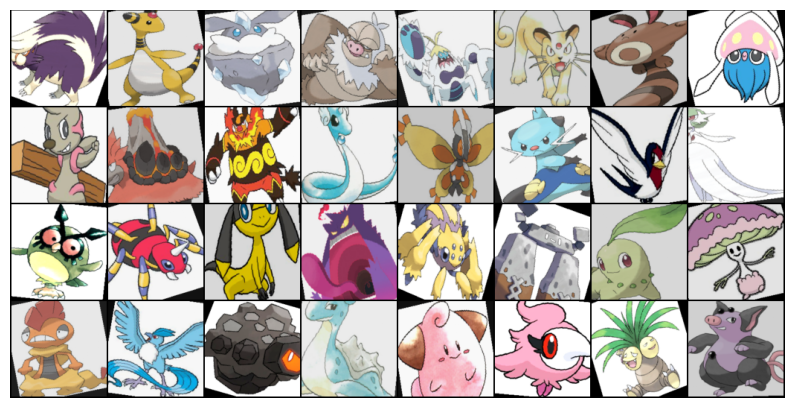

In [ ]:
images, labels = next(iter(type_train_loader))

grid = make_grid(images, nrow=8)

plt.figure(figsize=(10,10))
plt.imshow(grid.permute(1, 2, 0))
#plt.title([base_dataset.classes[l] for l in labels])
plt.axis("off")
plt.show()

In [ ]:
# Verificar que hay dentro del DataLoader
train_batches, labels = next(iter(type_train_loader))
print(train_batches.shape)
print(f"Label shape: {labels.shape}")
print(f"Label shape: {labels}")

torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])
Label shape: tensor([ 2, 13, 16, 12, 14,  8,  6,  5,  0,  2, 17, 16,  3,  5, 12, 12,  6, 15,
        10, 12, 17, 16, 15,  3,  4, 17,  9,  9,  3, 17, 15,  9])


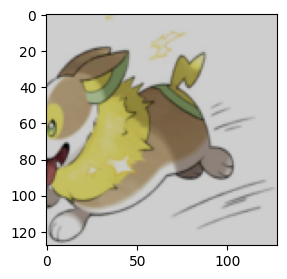

Electric


In [ ]:
random_idx = np.random.randint(0, len(train_batches))
random_batch = train_batches[random_idx]

fig = plt.figure(figsize = (3,3))
plt.imshow(random_batch.permute(1, 2, 0).numpy())
plt.show()
print(types[labels[random_idx].item()])

In [ ]:
#Configuración GPU - CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# 3. Arquitectura de CNN

## 3.1 Regresión de Stats

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class PokemonEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Cargar EfficientNet-B2 pre-entrenado
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        for name, param in self.backbone.named_parameters():
          if "features.6" in name or "features.7" in name:
            param.requires_grad = True
          else:
            param.requires_grad = False

        # Reemplazar la cabeza clasificadora
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


## 3.2 Clasificador de Tipos

In [ ]:
import torchvision.models as models

class PokemonTypeCNN_Transfer(nn.Module):
    """
    CNN para predecir el tipo primario de un Pokémon usando un backbone pre-entrenado.
    """
    def __init__(self, num_classes):
        super().__init__()

        # Cargar EfficientNet-B2
        self.backbone = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

        # No congelar parámetros, para que sean entrenables
        for param in self.backbone.parameters():
            param.requires_grad = True

        #obtener número de filtros para EfficientNet
        num_ftrs = self.backbone.classifier[1].in_features

        # Capa de salida
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes) # Salida de logits
        )

    def forward(self, x):
        return self.backbone(x)

# Inicializa el modelo
num_classes = len(label_map)
types_cnn_transfer = PokemonTypeCNN_Transfer(num_classes).to(device)
print(types_cnn_transfer)


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 174MB/s]


PokemonTypeCNN_Transfer(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
         

### 3.2.1 Dummy Types Testing

In [ ]:
dummy_x = torch.rand(1, 3, 128, 128).to(device)

types_cnn_transfer.eval()
with torch.inference_mode():
    dummy_y = types_cnn_transfer(dummy_x)

print(dummy_y.shape)
print(f"Tamaño del Clasificador: {dummy_y.shape}")
print(f"Datos del clasificador: {dummy_y}")


torch.Size([1, 18])
Tamaño del Clasificador: torch.Size([1, 18])
Datos del clasificador: tensor([[ 0.0604, -0.0322, -0.0749, -0.0706, -0.0476,  0.0004,  0.0601, -0.0847,
         -0.0427, -0.0364, -0.0191, -0.0399, -0.0579, -0.0946,  0.1051, -0.0407,
          0.0113,  0.0347]], device='cuda:0')


## 3.3 Printing de la Arquitectura

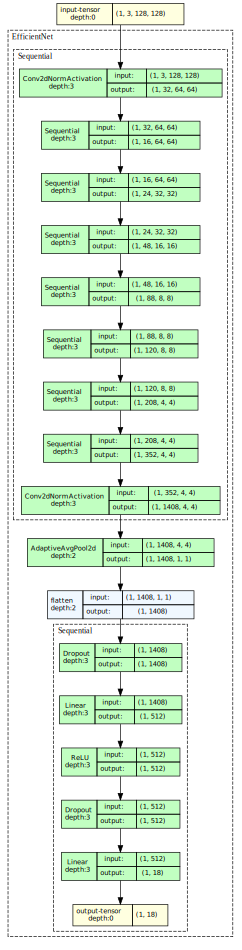

In [ ]:

model_diagram = draw_graph(
    types_cnn_transfer,
    input_size=(1, 3, 128, 128),
    expand_nested=True,
    save_graph=True,       # Saves automatically
    graph_dir="/content",  # Save location
    filename="pokemon_cnn"
)

model_diagram

model_diagram.visual_graph


In [ ]:

writer = SummaryWriter("runs/model_graph")
dummy = torch.randn(1, 3, 128, 128).to(device) # Move dummy tensor to the same device as the model
writer.add_graph(types_cnn_transfer, dummy)
writer.close()


# 5. Pokemon Type Classifier CNN

## 5.1 Accuracy & Loss

In [ ]:
def accuracy_fn(y_pred, y_true):
    """
    Computes classification accuracy.
    y_pred: logits from CNN, shape [B, num_classes]
    y_true: tensor of class indices, shape [B]
    """
    preds = torch.argmax(y_pred, dim=1)
    correct = (preds == y_true).sum().item()
    acc = correct / len(y_true)
    return acc


In [ ]:
loss_fn_type = nn.CrossEntropyLoss()
optimizer_type = torch.optim.Adam(types_cnn_transfer.parameters(), lr=0.0001)
#optimizer_type = torch.optim.SGD(types_cnn_transfer.parameters(), lr=0.001)


## 5.2 Train & Test Typing

In [ ]:
def train_type(dataloader: DataLoader, model: nn.Module, loss_fn, optimizer):
    model.train()

    train_loss = 0.0
    train_acc  = 0.0

    for data, target in dataloader:

        data = data.to(device)
        target = target.to(device)

        # Forward
        logits = model(data)
        loss = loss_fn(logits, target)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc  += accuracy_fn(logits, target)

    train_loss /= len(dataloader)
    train_acc  /= len(dataloader)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")

    return train_loss, train_acc


In [ ]:
def test_type(dataloader: DataLoader, model: nn.Module, loss_fn):
    model.eval()

    test_loss = 0.0
    test_acc  = 0.0

    with torch.inference_mode():
        for data, target in dataloader:

            data = data.to(device)
            target = target.to(device)  # Class index as int64

            # Forward
            logits = model(data)

            loss = loss_fn(logits, target)
            test_loss += loss.item()

            # Accuracy
            test_acc += accuracy_fn(logits, target)

    test_loss /= len(dataloader)
    test_acc  /= len(dataloader)

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

    return test_loss, test_acc

In [ ]:
def val_type(dataloader: DataLoader, model: nn.Module, loss_fn):
    model.eval()

    val_loss = 0.0
    val_acc  = 0.0

    with torch.inference_mode():
        for data, target in dataloader:

            data = data.to(device)
            target = target.to(device)  # Class index as int64

            # Forward
            logits = model(data)

            loss = loss_fn(logits, target)
            val_loss += loss.item()

            # Accuracy
            val_acc += accuracy_fn(logits, target)

    val_loss /= len(dataloader)
    val_acc  /= len(dataloader)

    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")

    return val_loss, val_acc

## 5.3 Data Visualization

In [ ]:
EPOCHS = 20

#conjunto validación
type_loss_val = []
type_acc_val = [] # Renamed from type_acc_train


type_loss_train = []
type_acc_train = [] # Renamed from type_acc_train
type_loss_test = []
type_acc_test = []  # Renamed from type_acc_test

for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch: {epoch}\n--------" )
    train_loss, train_acc = train_type(type_train_loader, types_cnn_transfer, loss_fn_type, optimizer_type)
    val_loss, val_acc = val_type(type_val_loader, types_cnn_transfer, loss_fn_type)
    test_loss, test_acc = test_type(type_test_loader, types_cnn_transfer, loss_fn_type)     # Renamed test_acc to test_mae

    type_loss_train.append(train_loss)
    type_loss_test.append(test_loss)
    type_loss_val.append(val_loss)
    type_acc_train.append(train_acc) # Appending to type_acc_train
    type_acc_test.append(test_acc)

    type_acc_val.append(val_acc)


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0
--------
Train Loss: 0.0399 | Train Acc: 98.80%
Val Loss: 1.3535 | Val Accuracy: 70.81%
Test Loss: 0.0004 | Test Accuracy: 100.00%
Epoch: 1
--------
Train Loss: 0.0435 | Train Acc: 98.39%
Val Loss: 1.2287 | Val Accuracy: 70.37%
Test Loss: 0.0001 | Test Accuracy: 100.00%
Epoch: 2
--------
Train Loss: 0.0551 | Train Acc: 98.55%
Val Loss: 1.2188 | Val Accuracy: 71.73%
Test Loss: 0.0000 | Test Accuracy: 100.00%
Epoch: 3
--------
Train Loss: 0.0444 | Train Acc: 98.83%
Val Loss: 1.2140 | Val Accuracy: 73.78%
Test Loss: 0.0005 | Test Accuracy: 100.00%
Epoch: 4
--------
Train Loss: 0.0613 | Train Acc: 97.72%
Val Loss: 1.1460 | Val Accuracy: 74.14%
Test Loss: 0.0004 | Test Accuracy: 100.00%
Epoch: 5
--------
Train Loss: 0.0508 | Train Acc: 98.44%
Val Loss: 1.3829 | Val Accuracy: 71.20%
Test Loss: 0.0000 | Test Accuracy: 100.00%
Epoch: 6
--------
Train Loss: 0.0257 | Train Acc: 99.48%
Val Loss: 1.3447 | Val Accuracy: 70.96%
Test Loss: 0.0000 | Test Accuracy: 100.00%
Epoch: 7
--------
Tr

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Add training loss line (dark grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_loss_train,
    mode='lines',
    name='Loss train',
    line=dict(color='#3a3a3a', width=2.5)  # Dark grey
))

# Add test loss line (medium grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_loss_test,
    mode='lines',
    name='Loss test',
    line=dict(color='#6b6b6b', width=2.5)  # Medium grey
))

# Update layout with NieR: Automata terminal aesthetic
fig.update_layout(
    title='Loss',
    xaxis_title='Epochs',
    yaxis_title='Loss',
    width=700,
    height=420,
    plot_bgcolor='#e8dcc8',  # Light cream background
    paper_bgcolor='#e8dcc8',
    font=dict(color='#3a3a3a', size=12, family='monospace'),
    xaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    yaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    legend=dict(
        bgcolor='rgba(232,220,200,0.9)',
        bordercolor='#6b6b6b',
        borderwidth=1,
        font=dict(color='#3a3a3a')
    )
)

fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Add training loss line (dark grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_acc_train,
    mode='lines',
    name='Accuracy train',
    line=dict(color='#3a3a3a', width=2.5)  # Dark grey
))

# Add test loss line (medium grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_acc_test,
    mode='lines',
    name='Accuracy test',
    line=dict(color='#6b6b6b', width=2.5)  # Medium grey
))

# Update layout with NieR: Automata terminal aesthetic
fig.update_layout(
    title='Acc',
    xaxis_title='Epochs',
    yaxis_title='Acc',
    width=700,
    height=420,
    plot_bgcolor='#e8dcc8',  # Light cream background
    paper_bgcolor='#e8dcc8',
    font=dict(color='#3a3a3a', size=12, family='monospace'),
    xaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    yaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    legend=dict(
        bgcolor='rgba(232,220,200,0.9)',
        bordercolor='#6b6b6b',
        borderwidth=1,
        font=dict(color='#3a3a3a')
    )
)

fig.show()

## 5.4 Confusion Matrix & Stats

In [ ]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import confusion_matrix

# Pokémon type color mapping (official colors)
type_colors = {
    'Bug': '#A8B820',
    'Dark': '#705848',
    'Dragon': '#7038F8',
    'Electric': '#F8D030',
    'Fairy': '#EE99AC',
    'Fighting': '#C03028',
    'Fire': '#F08030',
    'Flying': '#A890F0',
    'Ghost': '#705898',
    'Grass': '#78C850',
    'Ground': '#E0C068',
    'Ice': '#98D8D8',
    'Normal': '#A8A878',
    'Poison': '#A040A0',
    'Psychic': '#F85888',
    'Rock': '#B8A038',
    'Steel': '#B8B8D0',
    'Water': '#6890F0'
}

# Get confusion matrix data
types_cnn_transfer.eval()
y_true = []
y_preds = []
with torch.inference_mode():
    for X, y in type_test_loader:
        X = X.to(device)
        y = y.to(device)
        logits = types_cnn_transfer(X)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(y.cpu().numpy())
        y_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_preds, labels=list(label_map.values()))
labels = list(label_map.keys())

# Create custom colored confusion matrix
fig = go.Figure()

# Add heatmap with custom hover text
hover_text = []
for i in range(len(labels)):
    hover_row = []
    for j in range(len(labels)):
        hover_row.append(f'True: {labels[i]}<br>Pred: {labels[j]}<br>Count: {cm[i][j]}')
    hover_text.append(hover_row)

fig.add_trace(go.Heatmap(
    z=cm,
    x=labels,
    y=labels,
    hovertext=hover_text,
    hoverinfo='text',
    colorscale='Blues',
    showscale=True,
    colorbar=dict(title="Count")
))

# Add text annotations with values
annotations = []
for i in range(len(labels)):
    for j in range(len(labels)):
        # Determine text color based on cell value for readability
        text_color = 'white' if cm[i][j] > cm.max() / 2 else 'black'
        annotations.append(
            dict(
                x=labels[j],
                y=labels[i],
                text=str(cm[i][j]),
                showarrow=False,
                font=dict(color=text_color, size=10)
            )
        )

# Add colored borders/markers for each type
shapes = []
for i, type_name in enumerate(labels):
    color = type_colors[type_name]
    # Left border for y-axis
    shapes.append(dict(
        type='rect',
        x0=-0.6, x1=-0.4,
        y0=i-0.4, y1=i+0.4,
        fillcolor=color,
        line=dict(width=0)
    ))
    # Top border for x-axis
    shapes.append(dict(
        type='rect',
        x0=i-0.4, x1=i+0.4,
        y0=-0.6, y1=-0.4,
        fillcolor=color,
        line=dict(width=0)
    ))

fig.update_layout(
    title='Confusion Matrix - Pokémon Type Classification',
    xaxis=dict(
        title='Predicted Type',
        side='bottom',
        tickangle=45,
        showgrid=False
    ),
    yaxis=dict(
        title='True Type',
        showgrid=False,
        autorange='reversed'
    ),
    width=900,
    height=900,
    plot_bgcolor='#e8dcc8',
    paper_bgcolor='#e8dcc8',
    font=dict(color='#3a3a3a', size=11),
    shapes=shapes,
    annotations=annotations
)

fig.show()


# 6. Evaluación Final con el Conjunto de Prueba

In [ ]:
fig = go.Figure()

# Add training loss line (dark grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_loss_val,
    mode='lines',
    name='Loss VAL',
    line=dict(color='#3a3a3a', width=2.5)  # Dark grey
))

# Add test loss line (medium grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_loss_test,
    mode='lines',
    name='Loss test',
    line=dict(color='#6b6b6b', width=2.5)  # Medium grey
))

# Update layout with NieR: Automata terminal aesthetic
fig.update_layout(
    title='Loss',
    xaxis_title='Epochs',
    yaxis_title='Loss: Train VS Val',
    width=700,
    height=420,
    plot_bgcolor='#e8dcc8',  # Light cream background
    paper_bgcolor='#e8dcc8',
    font=dict(color='#3a3a3a', size=12, family='monospace'),
    xaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    yaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    legend=dict(
        bgcolor='rgba(232,220,200,0.9)',
        bordercolor='#6b6b6b',
        borderwidth=1,
        font=dict(color='#3a3a3a')
    )
)

fig.show()

In [ ]:
fig = go.Figure()

# Add training loss line (dark grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_acc_val,
    mode='lines',
    name='Accuracy VAL',
    line=dict(color='#3a3a3a', width=2.5)  # Dark grey
))

# Add test loss line (medium grey)
fig.add_trace(go.Scatter(
    x=list(range(1, EPOCHS+1)),
    y=type_acc_test,
    mode='lines',
    name='Accuracy test',
    line=dict(color='#6b6b6b', width=2.5)  # Medium grey
))

# Update layout with NieR: Automata terminal aesthetic
fig.update_layout(
    title='Accuracy VAL VS Test',
    xaxis_title='Epochs',
    yaxis_title='Acc',
    width=700,
    height=420,
    plot_bgcolor='#e8dcc8',  # Light cream background
    paper_bgcolor='#e8dcc8',
    font=dict(color='#3a3a3a', size=12, family='monospace'),
    xaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    yaxis=dict(
        gridcolor='#d0c4b0',
        showgrid=True,
        zeroline=False,
        linecolor='#6b6b6b'
    ),
    legend=dict(
        bgcolor='rgba(232,220,200,0.9)',
        bordercolor='#6b6b6b',
        borderwidth=1,
        font=dict(color='#3a3a3a')
    )
)

fig.show()